# GAN Body Lab: Generación de Cuerpos Humanos 3D y 2D

Este notebook presenta el pipeline completo de un proyecto basado en Redes Generativas Antagónicas (GANs) para la generación de modelos humanos. El repositorio aborda la síntesis de cuerpos desde dos perspectivas complementarias:

1. **Pipeline Tabular a Geometría (WGAN-GP Condicional + SMPL):** A partir de 10 medidas antropométricas básicas, el modelo genera parámetros de forma (`betas`) compatibles con el modelo SMPL (Skinned Multi-Person Linear Model). Posteriormente, estos parámetros permiten instanciar mallas 3D o proyecciones ortográficas 2D.
2. **Pipeline de Imagen Directa (DCGAN + WGAN-GP):** Una rama puramente visual que aprende la distribución de siluetas humanas utilizando el dataset TNT15.

A lo largo de este documento, explicaremos el marco metodológico, justificaremos las decisiones arquitectónicas (como el uso de WGAN-GP) y proporcionaremos celdas de código para ejecutar secuencialmente todo el ciclo de vida del proyecto.

## 1. Fundamentos Teóricos

### 1.1 Wasserstein GAN con Gradient Penalty (WGAN-GP)
Las GANs tradicionales sufren frecuentemente de inestabilidad durante el entrenamiento (colapso de modo, desvanecimiento de gradientes). Para mitigar estos problemas, este proyecto emplea **WGAN-GP**.

En lugar de minimizar la divergencia de Jensen-Shannon, WGAN minimiza la distancia de Wasserstein (Earth-Mover's distance). La función de valor se define como:

$$\min_G \max_{D \in \mathcal{D}} \mathbb{E}_{\mathbf{x} \sim \mathbb{P}_r}[D(\mathbf{x})] - \mathbb{E}_{\mathbf{\tilde{x}} \sim \mathbb{P}_g}[D(\mathbf{\tilde{x}})]$$

Para garantizar que el Discriminador (o *Crítico*) cumpla la restricción de Lipschitz (1-Lipschitz), WGAN-GP introduce una penalización sobre la norma del gradiente:

$$L = \underbrace{\mathbb{E}[D(\mathbf{\tilde{x}})] - \mathbb{E}[D(\mathbf{x})]}_{\text{Wasserstein Loss}} + \lambda \underbrace{\mathbb{E}_{\mathbf{\hat{x}}}[(||\nabla_{\mathbf{\hat{x}}} D(\mathbf{\hat{x}})||_2 - 1)^2]}_{\text{Gradient Penalty}}$$

Donde $\lambda$ es el coeficiente de penalización (típicamente $\lambda=10$).

### 1.2 El Modelo SMPL
El SMPL es un modelo paramétrico del cuerpo humano. En este proyecto nos centramos en el componente de **forma** (shape), controlado por 10 coeficientes principales derivados de un Análisis de Componentes Principales (PCA) sobre escaneos 3D reales. La rama tabular predice exactamente estos 10 coeficientes (`betas`).

## 2. Preparación del Entorno

A continuación, configuramos el entorno y silenciamos advertencias de librerías legacy como `chumpy` (usada internamente por SMPL).

In [1]:
import os
import sys
import warnings

# Aseguramos que el directorio raíz está en el PATH de Python
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

from src.config.paths import Paths
Paths.init_project()
print("✅ Entorno inicializado y rutas de proyecto configuradas.")

✅ Entorno inicializado y rutas de proyecto configuradas.


---
## 3. Pipeline Tabular: De Medidas a Geometría 3D

La rama tabular asocia un vector de 10 medidas (estatura, contorno de pecho, etc.) con los 10 parámetros PCA (`betas`) del modelo SMPL.

### 3.1 Ajuste de Betas (Pseudo-Ground Truth)
Dado que el dataset original (NOMO3D) contiene las 10 medidas físicas pero **no** los betas del modelo SMPL, el primer paso computacional es encontrar los betas que mejor se ajustan a esas medidas. Esto se realiza formulando un problema de optimización no lineal (resuelto mediante Gauss-Newton), minimizando la distancia entre las medidas predichas por la malla SMPL y las medidas reales del sujeto.

In [2]:
# Ejecución del ajuste de betas (Data Preparation)
# Nota: Si los betas ya han sido generados y cacheados en internal/data/betas_cache/,
# este paso será muy rápido. Si no, iterará sobre el dataset.
print("Iniciando el ajuste de Betas (fit)...")
!python ../main.py fit
print("✅ Ajuste completado.")

Iniciando el ajuste de Betas (fit)...
Fitting betas for 712 samples...
  Computing initial Jacobian for MALE...
Initializing SMPL measurer
    meas_zero: [178.1 104.3  95.3 101.2  40.4  37.4  74.8  68.1  49.   30.3]
  Computing initial Jacobian for FEMALE...
Initializing SMPL measurer
    meas_zero: [164.8  98.2  84.6 102.5  33.8  32.8  70.8  60.6  49.2  28.4]
100%|██████████████████████████████████████| 712/712 [00:00<00:00, 96683.00it/s]
Done. Fit 0 samples; stats appended to /home/sant_vz6/Escritorio/UA-3/4_NN-DL/GAN/internal/logs/beta_fit_stats.csv
✅ Ajuste completado.


### 3.2 Entrenamiento del WGAN-GP Tabular

El Generador recibe ruido latente $z$ concatenado con el vector de 10 medidas normalizadas, y predice 10 `betas`. El Crítico evalúa la plausibilidad de los `betas` generados frente a los `betas` reales, condicionado siempre a las medidas introducidas.

- **Generador:** Perceptrón Multicapa (MLP) condicional con un bloque residual (Skip Connection) para mejorar el flujo de gradientes.
- **Crítico:** MLP que emite un valor escalar de "realismo" (no acotado en $[0, 1]$ porque usa distancia de Wasserstein).

In [3]:
# Entrenamiento del modelo tabular.
# Descomentar la siguiente línea para ejecutar el entrenamiento.
# Advertencia: Esto puede tomar tiempo dependiendo del hardware disponible.

# !python ../main.py train

### 3.3 Evaluación del Modelo

La evaluación se realiza cargando el último checkpoint entrenado y generando formas 3D sobre el conjunto de test. Una vez generados los betas para las medidas de prueba, instanciamos la malla SMPL, la medimos con los regresores virtuales y calculamos el Error Absoluto Medio (MAE) entre las medidas solicitadas y las medidas físicamente obtenidas.

In [4]:
# Evaluación del modelo tabular
!python ../main.py eval

Loading checkpoint /home/sant_vz6/Escritorio/UA-3/4_NN-DL/GAN/internal/experiments/wgangp_ckpt_2999.pt...
Initializing SMPL measurer
Evaluating...
100%|███████████████████████████████████████████| 72/72 [00:07<00:00,  9.73it/s]

--- Evaluation Results ---
         Measurement  MAE (cm)
     Head_Top_Height 22.290581
           BUST_Circ 64.817635
   NaturalWAIST_Circ 61.794726
            HIP_Circ  5.015670
       NeckBase_Circ  2.688681
Shoulder_to_Shoulder  5.416291
              Inseam  8.991001
          Thigh_Circ  9.045819
          Bicep_Circ  3.972925


### 3.4 Inferencia y Renderizado (2D y 3D)

Una vez validado el modelo, podemos proporcionar medidas antropométricas arbitrarias para generar la representación digital. La salida puede exportarse como una imagen proyectada (PNG) o como una malla (OBJ) integrable en motores de renderizado o videojuegos.

In [5]:
# Inferencia: Sujeto Femenino, 170cm altura, usando configuración por defecto
# Generando ambas salidas: malla 3D y render 2D frontal.
!python ../main.py infer --gender FEMALE --height 170 --output both --view front

Loaded checkpoint: wgangp_ckpt_2999.pt
Normalised cond: [[ 0.28150764  0.889512    0.726724   -0.97357523 -1.3258042  -0.61685514
   0.14593916 -0.03841961 -0.57458633 -1.1062855 ]]
Generated betas (avg of 32): [[ 1.6209812  2.7730474  2.7738352  2.9068975 -2.9562123  2.2033756
   2.8633664 -2.746677   2.719655  -2.9479127]]
Initializing SMPL measurer
Mesh saved to /home/sant_vz6/Escritorio/UA-3/4_NN-DL/GAN/internal/temp/generated_FEMALE_170.obj
2D image saved to /home/sant_vz6/Escritorio/UA-3/4_NN-DL/GAN/internal/temp/generated_FEMALE_170_front.png


Mostrando render: ../internal/temp/generated_FEMALE_170_front.png


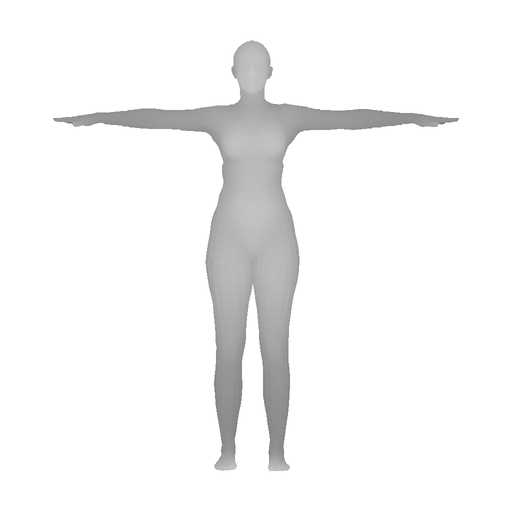

In [6]:
from IPython.display import Image, display
import glob

# Visualizar el resultado 2D generado
images = glob.glob("../internal/temp/*_front.png")
if images:
    latest_image = max(images, key=os.path.getctime)
    print(f"Mostrando render: {latest_image}")
    display(Image(filename=latest_image))
else:
    print("No se encontró imagen generada.")

---
## 4. Pipeline de Imagen: WGAN-GP sobre TNT15

Esta segunda rama del proyecto abandona el paradigma tabular condicional para enfocarse en la generación directa de píxeles empleando capas convolucionales transpuestas (DCGAN architecture).

- **Imágenes:** Resoluciones de 64x64 en escala de grises. Se utilizan siluetas humanas segmentadas del dataset TNT15.
- **Arquitectura:** 
  - Generador: Transposed Convolutions progresivas (e ej., de $4 \times 4$ a $64 \times 64$).
  - Discriminador: Convoluciones normales con *GroupNorm* (para WGAN-GP es incompatible usar BatchNorm en el crítico, ya que arruina la penalización de gradiente independiente por muestra).

In [7]:
# Entrenamiento del GAN de imágenes en TNT15.
# Descomentar para entrenar. Requiere el dataset en internal/data/tnt15/ o TNT15_ROOT.

# !python ../main.py train_img

### 4.1 Inferencia de la rama de Imágenes

El comando `infer_img` carga el último checkpoint del generador convolucional y sintetiza nuevas muestras visuales a partir de tensores de ruido normales puros.

In [8]:
# Generar un grid de 16 imágenes con el modelo entrenado (si existe el checkpoint)
!python ../main.py infer_img -n 16 --grid

Loaded checkpoint: wgangp_img_ckpt_99.pt
Saved grid -> /home/sant_vz6/Escritorio/UA-3/4_NN-DL/GAN/internal/temp/generated_grid_16.png


Mostrando grid: ../internal/temp/generated_grid_16.png


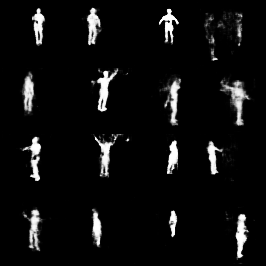

In [9]:
# Mostrar el grid generado
grids = glob.glob("../internal/temp/generated_grid_*.png")
if grids:
    latest_grid = max(grids, key=os.path.getctime)
    print(f"Mostrando grid: {latest_grid}")
    display(Image(filename=latest_grid))
else:
    print("No se encontró el grid generado. Probablemente requiera entrenamiento previo.")

## 5. Conclusiones y Posibles Mejoras

El uso de **WGAN-GP** ha demostrado estabilizar significativamente la convergencia en contraposición a configuraciones GAN estándar, evitando tanto desvanecimiento de gradientes como colapsos de modo severos. 

**Líneas futuras de desarrollo:**
1. **Representación 3D integral:** Integrar el motor gráfico (como PyTorch3D o trimesh) de forma más acoplada a la función de pérdida para propagar errores geométricos visuales directamente al generador tabular.
2. **Condicionamiento en Rama de Imagen:** Modificar la WGAN de imágenes para que pueda recibir condiciones (ej., pose 2D o género) mediante proyecciones en el discriminador y capas de AdaIN en el generador.
3. **Dataset Tabular más Extenso:** CAESAR o bases de datos antropométricas modernas proporcionarían mayor variabilidad natural.